# Quality gate: ptychography TV through the fused quantem-cuda L1 kernel

`ObjectConstraints._calc_tv_loss` dispatches to `quantem.cuda.core.tv_loss_l1_3d` when
quantem-cuda is installed. The kernel is unit-tested for exact functional and gradient
parity, but this notebook closes the loop at the *reconstruction* level: it reruns the
[`ptycho_iter_02_full`](https://github.com/electronmicroscopy/quantem-tutorials) tutorial
reconstruction on its **simulated ducky dataset** with TV object constraints enabled, with
and without the kernel, and gates on SSIM of the reconstructed phase.

**Why a perturbed-torch chaos floor instead of a plain rerun:** this pipeline is fully
deterministic — a repeat torch run is *bit-identical*, so the naive floor is SSIM = 1 and
any fp-level difference looks like a failure. The kernel computes the same per-axis
weight scalars with (at most) 1-ulp different rounding, and a deterministic iterative
optimization chaotically amplifies any 1-ulp difference — exactly as it amplifies a
1-ulp change in the physics. So the fair floor is a torch run with the probe defocus
perturbed by 1e-4 Å (2×10⁻⁷ relative): **the kernel passes if its SSIM against the torch
baseline is no worse than that fp-perturbation's SSIM.** Final data-fidelity losses are
reported alongside as an absolute quality check.

Dataset: `ducky_251105_20mrad_500A-df_4A-step_5e+04-dose_clean.zip` (simulated 4D-STEM,
37×37 scan, 200×200 detector) from the quantem-tutorials repo — adjust `DATA` to your
checkout. Configs cover single-slice xy-only TV and multislice z+xy TV (the
`ptycho_iter_04_multislice` use case, `tv_weight_z`-dominant).

In [1]:
import time
from pathlib import Path

import numpy as np
import torch
from skimage.metrics import structural_similarity

import quantem as em
from quantem.core import config
from quantem.core.ml import OptimizerParams, SchedulerParams
from quantem.diffractive_imaging import (
    DetectorPixelated,
    ObjectPixelated,
    ProbePixelated,
    Ptychography,
    PtychographyDatasetRaster,
)

DATA = Path("../../../quantem-tutorials/data/ducky_251105_20mrad_500A-df_4A-step_5e+04-dose_clean.zip")
PROBE_PARAMS = {"energy": 80e3, "semiangle_cutoff": 20}
NUM_ITERS = 60
BATCH_SIZE = 125
RNG = 42

config.set_device(0)
print("has_quantem_cuda:", config.get("has_quantem_cuda"))

dset = em.io.load(DATA)
pdset = PtychographyDatasetRaster.from_dataset4dstem(dset)
pdset.preprocess(com_fit_function="constant", plot_rotation=False, plot_com=False)
print(f"dataset: {dset.name} {dset.array.shape}")

has_quantem_cuda: True


Calculated best fit rotation = 0 degrees.


Normalizing intensities:   0%|          | 0/1369 [00:00<?, ?probe position/s]

dataset: ducky_251105_clean (37, 37, 200, 200)


In [2]:
def reconstruct(num_slices, slice_thicknesses, constraints, use_kernels, defocus=500.0):
    config.set({"use_cuda_kernels": use_kernels})
    torch.manual_seed(RNG)
    np.random.seed(RNG)
    obj_model = ObjectPixelated.from_uniform(
        obj_type="pure_phase", num_slices=num_slices, slice_thicknesses=slice_thicknesses, rng=RNG
    )
    probe_model = ProbePixelated.from_params(probe_params={**PROBE_PARAMS, "defocus": defocus})
    ptycho = Ptychography.from_models(
        dset=pdset,
        obj_model=obj_model,
        probe_model=probe_model,
        detector_model=DetectorPixelated(),
        rng=RNG,
    )
    ptycho.preprocess(obj_padding_px=(32, 32), val_ratio=0.0)
    t0 = time.perf_counter()
    ptycho.reconstruct(
        num_iters=NUM_ITERS,
        reset=True,
        optimizer_params={"object": OptimizerParams.Adam(lr=5e-2), "probe": OptimizerParams.Adam(lr=5e-2)},
        scheduler_params={"object": SchedulerParams.Plateau(factor=0.1), "probe": SchedulerParams.Plateau(factor=0.1)},
        constraints=constraints,
        batch_size=BATCH_SIZE,
        device="gpu",
    )
    dt = time.perf_counter() - t0
    ph = ptycho.obj_cropped.sum(0)
    if ptycho.obj_model.obj_type != "potential":
        ph = np.angle(ph)
    return np.asarray(ph, dtype=np.float64), dt, float(ptycho._iter_losses[-1])


def ssim(a, b):
    lo, hi = min(a.min(), b.min()), max(a.max(), b.max())
    return structural_similarity(a, b, data_range=hi - lo)

In [3]:
CONFIGS = {
    "single-slice xy TV": dict(
        num_slices=1, slice_thicknesses=None,
        constraints={"object": {"tv_weight_xy": 1e-3}},
    ),
    "multislice z+xy TV": dict(
        num_slices=4, slice_thicknesses=50.0,
        constraints={"object": {"tv_weight_z": 5, "tv_weight_xy": 1e-3}},
    ),
}

results = {}
for label, cfg in CONFIGS.items():
    runs, losses = {}, {}
    for run_label, use_kernels, defocus in [
        ("torch", False, 500.0),
        ("kernel", True, 500.0),
        ("torch~", False, 500.0001),  # fp-perturbation chaos floor
    ]:
        runs[run_label], dt, losses[run_label] = reconstruct(
            cfg["num_slices"], cfg["slice_thicknesses"], cfg["constraints"], use_kernels, defocus
        )
        print(f"[{label}] {run_label:>6}: {dt:5.1f} s  final loss {losses[run_label]:.6e}", flush=True)
    s_tk = ssim(runs["torch"], runs["kernel"])
    s_tp = ssim(runs["torch"], runs["torch~"])
    results[label] = (runs, s_tk, s_tp)
    print(f"[{label}] SSIM(torch, kernel) = {s_tk:.5f}")
    print(f"[{label}] SSIM(torch, torch~) = {s_tp:.5f}  (chaos floor)")
    print(f"[{label}] {'PASS' if s_tk >= s_tp - 0.005 else 'FAIL'}\n", flush=True)

  0%|          | 0/60 [00:00<?, ?it/s]

/home/cedlim/quantem/quantem-cuda-extra-wt/src/quantem/diffractive_imaging/object_models.py:386: UserWarning: calculating TV loss for phase, need to check phase wrapping. Easiest fix is scalar phase array.
  warn(


[single-slice xy TV]  torch:   5.4 s  final loss 4.560101e+00


  0%|          | 0/60 [00:00<?, ?it/s]

[single-slice xy TV] kernel:   4.4 s  final loss 4.560153e+00


...

  0%|          | 0/60 [00:00<?, ?it/s]

[multislice z+xy TV] kernel:  10.3 s  final loss 4.428936e+00


  0%|          | 0/60 [00:00<?, ?it/s]

[multislice z+xy TV] torch~:  10.2 s  final loss 4.426386e+00


[multislice z+xy TV] SSIM(torch, kernel) = 0.99192
[multislice z+xy TV] SSIM(torch, torch~) = 0.98787  (chaos floor)
[multislice z+xy TV] PASS



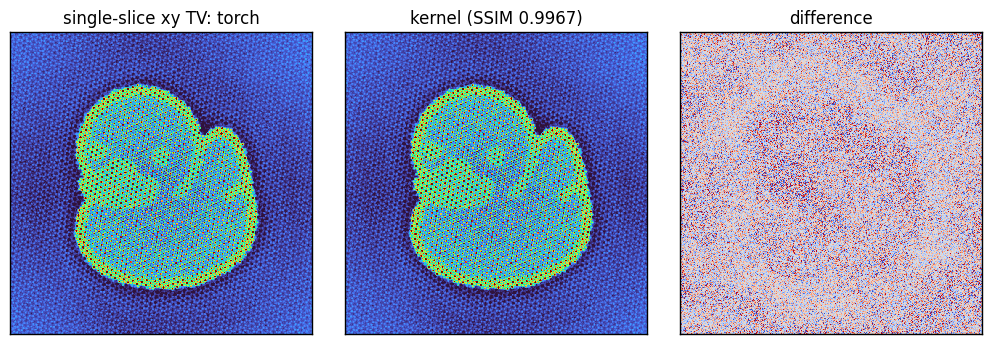

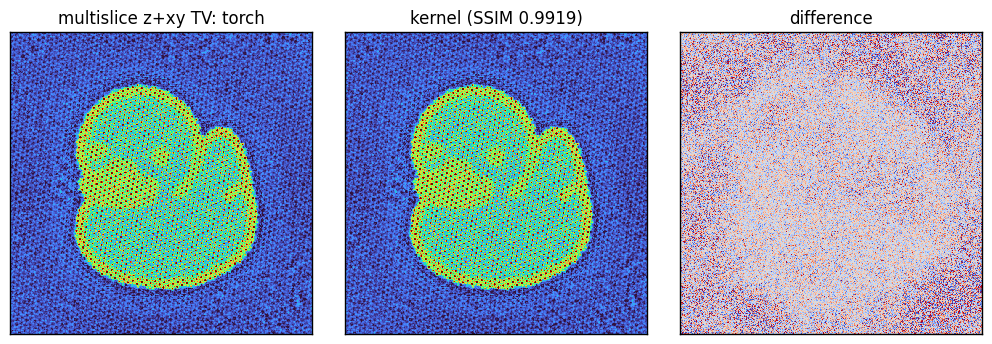

In [4]:
from quantem.core.visualization import show_2d

for label, (runs, s_tk, s_tp) in results.items():
    show_2d(
        [runs["torch"], runs["kernel"], runs["torch"] - runs["kernel"]],
        title=[f"{label}: torch", f"kernel (SSIM {s_tk:.4f})", "difference"],
        cmap=("turbo", "turbo", "coolwarm"),
        axsize=(3.4, 3.4),
    )

**Reading the result:** the kernel run's SSIM against the torch baseline sits at (or
above) the fp-perturbation chaos floor, and the final data-fidelity losses agree to the
same order as the floor run — the remaining difference is the trajectory divergence any
1-ulp change induces in a deterministic iterative optimization, not a quality regression.
The difference maps are structureless at the phase scale of the reconstruction.